In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [4]:
tickers = ["SPY", "^VIX"]

data = yf.download(tickers, start="2015-01-01", end="2025-01-01", auto_adjust=True)

prices = data["Close"].dropna()

prices.head()

[*********************100%***********************]  2 of 2 completed


Ticker,SPY,^VIX
Date,,
2015-01-02,170.125046,17.790001
2015-01-05,167.052643,19.920000
2015-01-06,165.479141,21.120001
2015-01-07,167.541245,19.309999
2015-01-08,170.514236,17.010000


In [5]:
returns = np.log(prices / prices.shift(1)).dropna()
returns.head()

Ticker,SPY,^VIX
Date,,
2015-01-05,-0.018225,0.113088
2015-01-06,-0.009464,0.058496
2015-01-07,0.012384,-0.089597
2015-01-08,0.017589,-0.126822
2015-01-09,-0.008046,0.031252


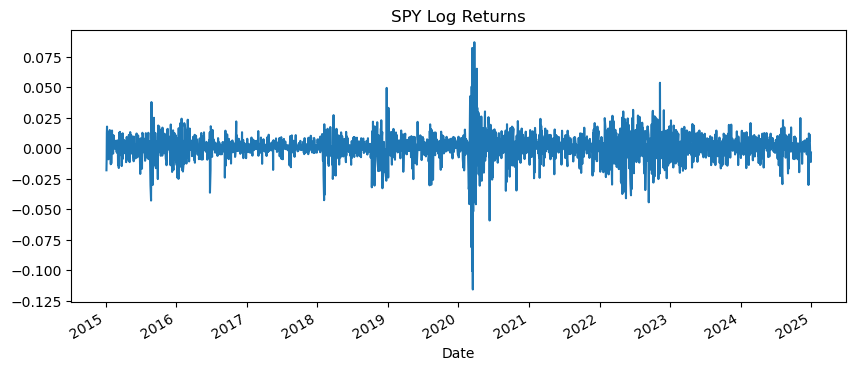

In [6]:
returns["SPY"].plot(title="SPY Log Returns", figsize=(10, 4))
plt.show()

In [7]:
prices.to_csv("../data/prices.csv")
returns.to_csv("../data/returns.csv")

In [8]:
# Use SPY log returns
spy_returns = returns["SPY"]

# 21 trading days ≈ 1 month
window = 21

# Realized volatility: rolling standard deviation of daily returns
realized_vol = spy_returns.rolling(window=window).std()

# Annualize volatility
realized_vol_annualized = realized_vol * np.sqrt(252)

realized_vol_annualized = realized_vol_annualized.dropna()

realized_vol_annualized.head()

Date
2015-02-03    0.178844
2015-02-04    0.167059
2015-02-05    0.165991
2015-02-06    0.161691
2015-02-09    0.150425
Name: SPY, dtype: float64

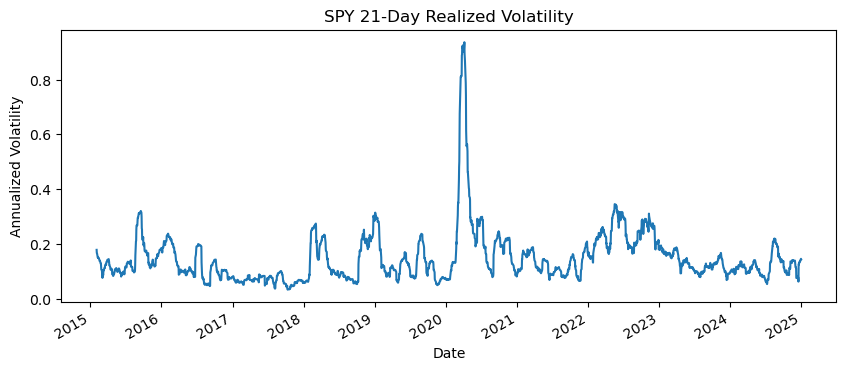

In [9]:
realized_vol_annualized.plot(
    title="SPY 21-Day Realized Volatility",
    figsize=(10, 4)
)

plt.ylabel("Annualized Volatility")
plt.show()

In [10]:
realized_vol_annualized.to_csv("../data/realized_volatility.csv")

In [11]:
vol = realized_vol_annualized.copy()

In [12]:
df = pd.DataFrame({
    "vol": vol,
    "vol_lag1": vol.shift(1),
    "vol_lag5": vol.shift(5),
    "vol_lag10": vol.shift(10),
    "vol_lag21": vol.shift(21)
})

In [13]:
df["target"] = df["vol"].shift(-1)

In [14]:
df = df.dropna()
df.head()

,vol,vol_lag1,vol_lag5,vol_lag10,vol_lag21,target
Date,,,,,,
2015-03-05,0.076598,0.088956,0.117697,0.138447,0.178844,0.092106
2015-03-06,0.092106,0.076598,0.106633,0.138762,0.167059,0.086750
2015-03-09,0.086750,0.092106,0.104769,0.130694,0.165991,0.104234
2015-03-10,0.104234,0.086750,0.092913,0.128510,0.161691,0.103367
2015-03-11,0.103367,0.104234,0.088956,0.128742,0.150425,0.106207


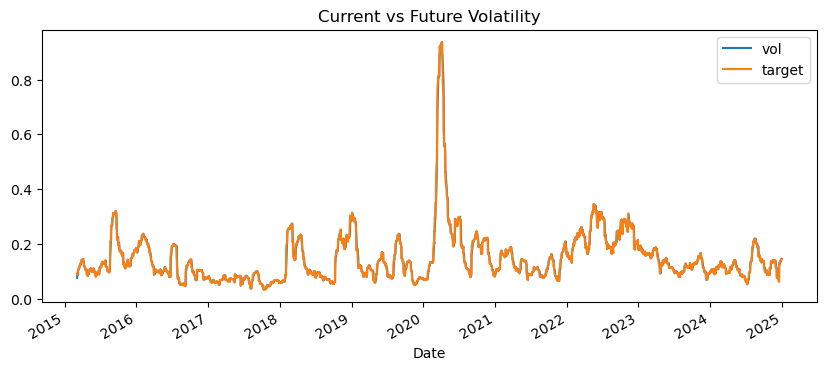

In [15]:
df[["vol", "target"]].plot(figsize=(10,4))
plt.title("Current vs Future Volatility")
plt.show()

In [16]:
df.to_csv("../data/model_data.csv")